In [13]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import optimize


In [14]:
#The dataset
data=np.loadtxt('logistic_regression_data.csv', delimiter=',', dtype=np.float64)
X,y=data[:,:-1], data[:,-1].reshape((-1,1))

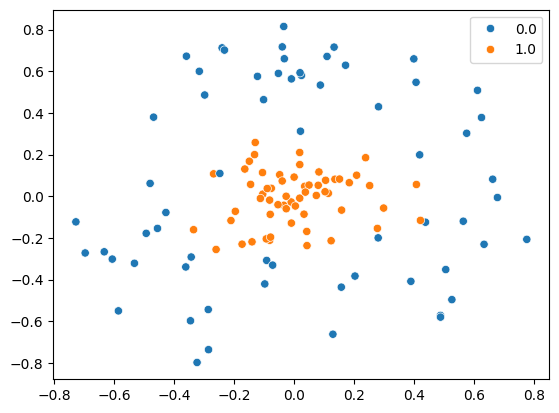

In [15]:
sns.scatterplot(x=X[:,0],y=X[:,1],hue=y.flatten())
plt.show()

In [16]:
#define sigmoid function 
def sigmoid(z):
   return 1/(1+np.exp(-z))

In [17]:
# the cross entropy loss function
def loss(theta,X,y):
    h=sigmoid(np.dot(X,theta))
    cos=-(np.sum(y*np.log(h)) +np.sum((1-y)*np.log(1-h)))/len(y)
    return cos

In [18]:
#gradient formula
def grad(theta,X,y):
    h=sigmoid(np.dot(X, theta))
    grad=np.dot(X.T,(h-y))/len(y)
    return grad

In [19]:
def expand_feature(x1, x2, power=2):
    #expand a 2d feature matrix to polynomial features up to the power 
    new_x=np.ones((x1.shape[0],1))
    for i in range (1, power+1):
        for j in range(i+1):
            new_x=np.append (new_x,(x1**(i-j)*(x2**j)).reshape(-1,1), axis=1)
    return new_x

In [20]:
def predict(theta,X):
    return(sigmoid(np.dot(X,theta))>0.5).flatten()

In [21]:
def gradient_descent(X,y,alpha,theta, num_iters):
    m=len(y)
    costs=[]

    for _ in range(num_iters):
        h=sigmoid(np.dot(X, theta))
        theta-=alpha*np.dot(X.T, (h-y))/m
        costs.append(loss(theta, X,y))
        



    return theta,costs

In [22]:
def logistics_regression(X, y, power=2, alpha=0.01, num_iters=100):
    X= expand_feature(X[:,0], X[:,1], power=power)
    theta=np.zeros((X.shape[1],1), dtype=np.float64)
    theta,costs=gradient_descent(X,y,alpha,theta, num_iters)
    predicted=predict(theta, X)
    return predicted,theta,costs

In [23]:
#decide the polynomial power in the features,abd the num of iterations 
power, num_iters=20, 20000
predicted, theta,costs= logistics_regression(X,y, power = power, alpha=0.6, num_iters=num_iters)

In [24]:
print('the accuracy is {:.2f}%'.format(sum(predicted==y.flatten()) /len(y)*100))

the accuracy is 95.08%


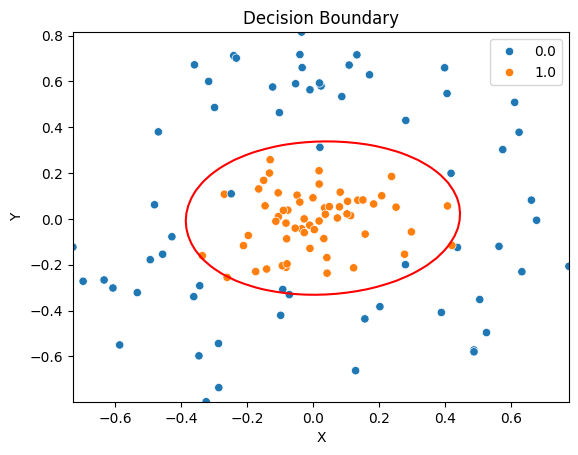

In [25]:
u = np.linspace(np.min(X[:,0]), np.max(X[:,0]), 50)
v = np.linspace(np.min(X[:,1]), np.max(X[:,1]), 50)

z = np.zeros((len(u), len(v)))

for i in range(len(u)):
    for j in range(len(v)):
        features = expand_feature(
            np.array([u[i]]),
            np.array([v[j]]),
            power=power
        )
        z[i, j] = np.dot(features, theta).item()   # Extract scalar

z = z.T

plt.contour(u, v, z, levels=[0], colors='red')
sns.scatterplot(x=X[:,0], y=X[:,1], hue=y.flatten())

plt.title("Decision Boundary")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

In [26]:
#LETS DO REGULARIZATION
#regularization :cost function
def cost_reg(theta,X,y, lam=0):
    h=sigmoid(np.dot(X,theta))
    theta1=theta.copy()
    theta1[0]=0
    cos=-(np.sum(y*np.log(h)) +np.sum((1-y)*np.log(1-h)))/len(y)+ lam*np.sum(theta1*theta1)/len(y)
    return cos

Regularization:gradient


In [27]:
#gradient formula
def grad_reg(theta,X,y,lam=0):
    h=sigmoid(np.dot(X, theta))
    theta1=theta.copy()
    theta1[0]=0
    grad=np.dot(X.T,(h-y))+2*lam*theta1/len(y)
    return grad

In [32]:
def gradient_descent_reg(X,y,alpha,theta,lam=0, num_iters=100):
    m=len(y)
    costs=[]

    for _ in range(num_iters):
        h=sigmoid(np.dot(X, theta))
        theta1=theta.copy()
        theta1[0]=0
        theta-=alpha*(np.dot(X.T,(h-y)) +2*lam*theta1)/m
        costs.append(cost_reg(theta,X,y))
        



    return theta,costs

In [33]:
def logistics_regression_reg(X, y, power=2, alpha=0.01, lam=0, num_iters=100):
    X= expand_feature(X[:,0], X[:,1], power=power)
    theta=np.zeros((X.shape[1],1), dtype=np.float64)
    theta,costs=gradient_descent_reg(X,y,alpha,theta, lam,num_iters)
    predicted=predict(theta, X)
    return predicted,theta,costs

In [34]:
#decide the polynomial power in the features,abd the num of iterations 
power, num_iters=20, 20000
lam=1
predicted, theta,costs= logistics_regression_reg(X,y, power = power, alpha=0.6, lam=lam,  num_iters=num_iters)

In [35]:
print('the accuracy is {:.2f}%'.format(sum(predicted==y.flatten()) /len(y)*100))

the accuracy is 87.70%


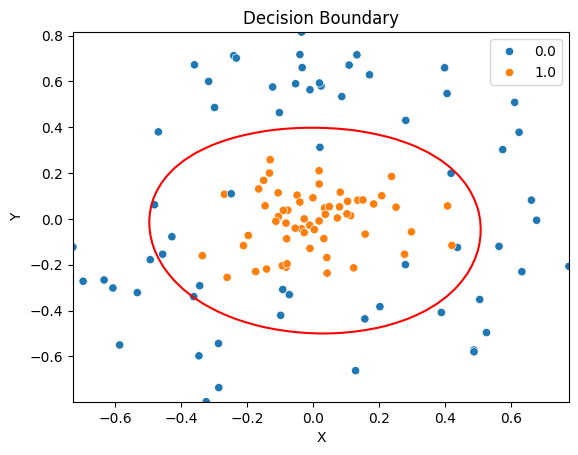

In [36]:
u = np.linspace(min(X[:,0]), max(X[:,0]), 50)
v = np.linspace(min(X[:,1]), max(X[:,1]), 50)

z = np.zeros((len(u), len(v)))

for i in range(len(u)):
    for j in range(len(v)):
        features = expand_feature(
            np.array([u[i]]),
            np.array([v[j]]),
            power=power
        )
        z[i, j] = np.dot(features, theta).item()   # Extract scalar

z = z.T

plt.contour(u, v, z, levels=[0], colors='red')
sns.scatterplot(x=X[:,0], y=X[:,1], hue=y.flatten())

plt.title("Decision Boundary")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()